In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix
from nltk.tokenize import word_tokenize
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.models import Model
from keras.layers import Input, Dense, LSTM, Dropout, concatenate
from keras.layers import Embedding
from keras.utils import plot_model

In [ ]:
df = pd.read_csv('all_agree.csv')
display(df.head())

,title,label,label_score
0,"Masuk Radar Pilwalkot Medan, Menantu Jokowi Be...",non-clickbait,0
1,Malaysia Sudutkan RI: Isu Kabut Asap hingga In...,non-clickbait,0
2,Viral! Driver Ojol di Bekasi Antar Pesanan Mak...,clickbait,1
3,"Kemensos Salurkan Rp 7,3 M bagi Korban Kerusuh...",non-clickbait,0
4,MPR: Amandemen UUD 1945 Tak Akan Melebar ke Ma...,non-clickbait,0


In [ ]:
df['label_score'].value_counts()

,count
label_score,
0,5297
1,3316


In [ ]:
def find_punch(x, punc):
  count = 0
  for char in x:
    if char == punc:
      count += 1
  return count

In [ ]:
df['title'].apply(lambda x: find_punch(x, '.'))
df['title'].apply(lambda x: find_punch(x, ','))
df['title'].apply(lambda x: find_punch(x, '?'))
df['title'].apply(lambda x: find_punch(x, '!'))
df['title'].apply(lambda x: find_punch(x, ';'))

,title
0,0
1,0
2,0
3,0
4,0
...,...
8608,0
8609,0
8610,0
8611,0


In [ ]:
def find_uppercase(x):
  count = 0
  for char in x:
    if char.isupper() :
      count +=1
  return count

def find_lowercase(x):
  count = 0
  for char in x:
    if char.islower() :
      count +=1
  return count

def find_number(x):
  return len(re.findall('[0-9]', x))

In [ ]:
df['uppercase_count'] = df['title'].apply(find_uppercase)
df['lowercase_count'] = df['title'].apply(find_lowercase)
df['number_count']    = df['title'].apply(find_number)

df['dot_count']       = df['title'].apply(lambda x: find_punch(x, '.'))
df['comma_count']     = df['title'].apply(lambda x: find_punch(x, ','))
df['question_count']  = df['title'].apply(lambda x: find_punch(x, '?'))
df['exclamation_count'] = df['title'].apply(lambda x: find_punch(x, '!'))
df['semicolon_count'] = df['title'].apply(lambda x: find_punch(x, ';'))
df['fullstop_count']  = df['title'].apply(lambda x: find_punch(x, '.'))

In [ ]:
df.shape

(8613, 12)

In [ ]:
import nltk
nltk.download('punkt_tab')
def clean(text):
    # Lowering letters
    text = text.lower()
    # Removing punctuations
    text = re.sub('[!?:;\'",.\-]', '', text)
    # Tokenization
    word_tokens = word_tokenize(text)
    # Joining words
    text = (' ').join(word_tokens)
    return text

<>:7: SyntaxWarning: invalid escape sequence '\-'
<>:7: SyntaxWarning: invalid escape sequence '\-'
/tmp/ipykernel_5702/1613162555.py:7: SyntaxWarning: invalid escape sequence '\-'
  text = re.sub('[!?:;\'",.\-]', '', text)
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
df['cleaned_title'] = df['title'].apply(clean)

In [ ]:
df[['title', 'label_score', 'comma_count', 'number_count',
    'uppercase_count', 'lowercase_count', 'question_count',
    'exclamation_count', 'dot_count', 'fullstop_count',
    'semicolon_count', 'cleaned_title']]

,title,label_score,comma_count,number_count,uppercase_count,lowercase_count,question_count,exclamation_count,dot_count,fullstop_count,semicolon_count,cleaned_title
0,"Masuk Radar Pilwalkot Medan, Menantu Jokowi Be...",0,1,0,13,45,0,0,0,0,0,masuk radar pilwalkot medan menantu jokowi ber...
1,Malaysia Sudutkan RI: Isu Kabut Asap hingga In...,0,0,0,9,37,0,0,0,0,0,malaysia sudutkan ri isu kabut asap hingga inv...
2,Viral! Driver Ojol di Bekasi Antar Pesanan Mak...,1,0,0,9,44,0,1,0,0,0,viral driver ojol di bekasi antar pesanan maka...
3,"Kemensos Salurkan Rp 7,3 M bagi Korban Kerusuh...",0,1,2,8,43,0,0,0,0,0,kemensos salurkan rp 73 m bagi korban kerusuha...
4,MPR: Amandemen UUD 1945 Tak Akan Melebar ke Ma...,0,0,4,11,28,0,0,0,0,0,mpr amandemen uud 1945 tak akan melebar ke man...
...,...,...,...,...,...,...,...,...,...,...,...,...
8608,Twice Rilis Teaser MV 'Feel Special' Jelang Co...,1,1,0,14,63,0,0,0,0,0,twice rilis teaser mv feel special jelang come...
8609,"Asap Karhutla Riau Mulai Merambah Ke Nias, BM...",0,1,0,13,38,0,0,0,0,0,asap karhutla riau mulai merambah ke nias bmkg...
8610,"Tolak RUU Pertanahan, Ribuan Petani Siap Gelar...",0,1,0,15,43,0,0,0,0,0,tolak ruu pertanahan ribuan petani siap gelar ...
8611,Ada Niat Tambah Momongan Tanpa Ikut Program Ha...,1,1,0,15,56,0,0,0,0,0,ada niat tambah momongan tanpa ikut program ha...


In [ ]:
display(df.head())

,title,label,label_score,uppercase_count,lowercase_count,number_count,dot_count,comma_count,question_count,exclamation_count,semicolon_count,fullstop_count,cleaned_title
0,"Masuk Radar Pilwalkot Medan, Menantu Jokowi Be...",non-clickbait,0,13,45,0,0,1,0,0,0,0,masuk radar pilwalkot medan menantu jokowi ber...
1,Malaysia Sudutkan RI: Isu Kabut Asap hingga In...,non-clickbait,0,9,37,0,0,0,0,0,0,0,malaysia sudutkan ri isu kabut asap hingga inv...
2,Viral! Driver Ojol di Bekasi Antar Pesanan Mak...,clickbait,1,9,44,0,0,0,0,1,0,0,viral driver ojol di bekasi antar pesanan maka...
3,"Kemensos Salurkan Rp 7,3 M bagi Korban Kerusuh...",non-clickbait,0,8,43,2,0,1,0,0,0,0,kemensos salurkan rp 73 m bagi korban kerusuha...
4,MPR: Amandemen UUD 1945 Tak Akan Melebar ke Ma...,non-clickbait,0,11,28,4,0,0,0,0,0,0,mpr amandemen uud 1945 tak akan melebar ke man...


In [ ]:
X = df.iloc[:, 3:]
y = df.iloc[:, 2]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=77
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(6890, 10)
(1723, 10)


In [ ]:
X_train_title = df['cleaned_title'].loc[X_train.index]
X_test_title  = df['cleaned_title'].loc[X_test.index]

In [ ]:
X_train_punc  = X_train.drop('cleaned_title', axis=1)
X_test_punc   = X_test.drop('cleaned_title', axis=1)

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train_title)

In [ ]:
X_train_title = tokenizer.texts_to_sequences(X_train_title)
X_test_title  = tokenizer.texts_to_sequences(X_test_title)

In [ ]:
tokenizer.word_index

{'di': 1,
 'ini': 2,
 'dan': 3,
 'yang': 4,
 'jadi': 5,
 'ke': 6,
 'kpk': 7,
 '2019': 8,
 'indonesia': 9,
 'tak': 10,
 'untuk': 11,
 'dengan': 12,
 'habibie': 13,
 'dari': 14,
 'polisi': 15,
 'dpr': 16,
 'saat': 17,
 'jokowi': 18,
 'soal': 19,
 'akan': 20,
 'uu': 21,
 'minta': 22,
 'baru': 23,
 'ada': 24,
 'bisa': 25,
 'hingga': 26,
 'mahasiswa': 27,
 'demo': 28,
 'bikin': 29,
 'asap': 30,
 'vs': 31,
 'anak': 32,
 'revisi': 33,
 'kota': 34,
 'papua': 35,
 '5': 36,
 '3': 37,
 'bj': 38,
 'hari': 39,
 'orang': 40,
 'tahun': 41,
 '4': 42,
 'usai': 43,
 'liga': 44,
 'sebut': 45,
 'warga': 46,
 'bakal': 47,
 '2': 48,
 'rumah': 49,
 'sinopsis': 50,
 'begini': 51,
 'dalam': 52,
 'dunia': 53,
 'gelar': 54,
 'kabut': 55,
 'ibu': 56,
 'rp': 57,
 'karena': 58,
 'mobil': 59,
 'jalan': 60,
 'sudah': 61,
 'jakarta': 62,
 'lebih': 63,
 'dki': 64,
 'siap': 65,
 'episode': 66,
 'korban': 67,
 'pemerintah': 68,
 'foto': 69,
 'masih': 70,
 'kasus': 71,
 'air': 72,
 'ingin': 73,
 'apa': 74,
 '2020': 75,
 '

In [ ]:
vocab_size = len(tokenizer.word_index)
vocab_size = len(tokenizer.word_index)
print(vocab_size)

12523


In [ ]:
lengths = []
for sentence in X_train_title:
    lengths.append(len(sentence))

print('Longest sentence  : ', np.max(lengths))
print('Shortest sentence : ', np.min(lengths))
print('Average length    : ', np.mean(lengths))

Longest sentence  :  19
Shortest sentence :  2
Average length    :  9.624528301886793


In [ ]:
X_train_title = pad_sequences(X_train_title, maxlen=19)
X_test_title  = pad_sequences(X_test_title,  maxlen=19)

In [ ]:
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train.values
)

class_weight_dict = dict(enumerate(class_weights))
print(class_weight_dict)

{0: np.float64(0.8086854460093896), 1: np.float64(1.3098859315589353)}


In [ ]:
tf.random.set_seed(99)

lstm_input  = Input(shape=(19,))
stm         = Embedding(vocab_size+1, 32, input_length=19)(lstm_input)
stm         = LSTM(3)(stm)
stm         = Dropout(rate=0.5)(stm)
lstm_output = stm

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
tf.random.set_seed(99)

lstm_input  = Input(shape=(19,))
stm         = Embedding(vocab_size+1, 32, input_length=19)(lstm_input)
stm         = LSTM(3)(stm)
stm         = Dropout(rate=0.5)(stm)
lstm_model  = Model(inputs=lstm_input, outputs=stm)

In [ ]:
mlp_input  = Input(shape=(19,))
dense      = Dense(3, activation='sigmoid')(mlp_input)
dense      = Dense(6, activation='sigmoid')(dense)
dense      = Dense(3, activation='sigmoid')(dense)
dense_input= Input(shape=(19,))
dense_model = Model(inputs=mlp_input, outputs=dense)

In [ ]:
dense_input = Input(shape=(9,))
dense       = Dense(3, activation='sigmoid')(dense_input)
dense       = Dense(6, activation='sigmoid')(dense)
dense       = Dense(3, activation='sigmoid')(dense)
dense_model = Model(inputs=dense_input, outputs=dense)

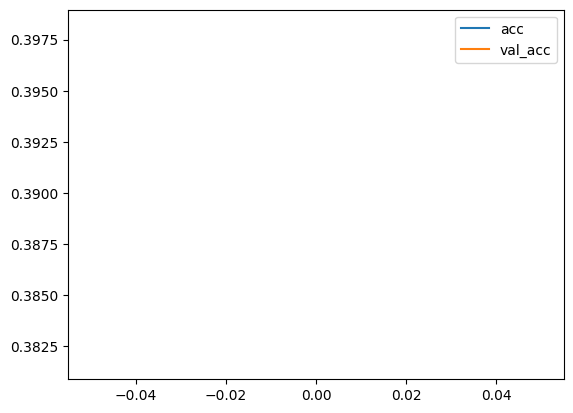

In [ ]:
plt.plot(history.history['acc'],     label='acc')
plt.plot(history.history['val_acc'], label='val_acc')
plt.legend(['acc', 'val_acc'])

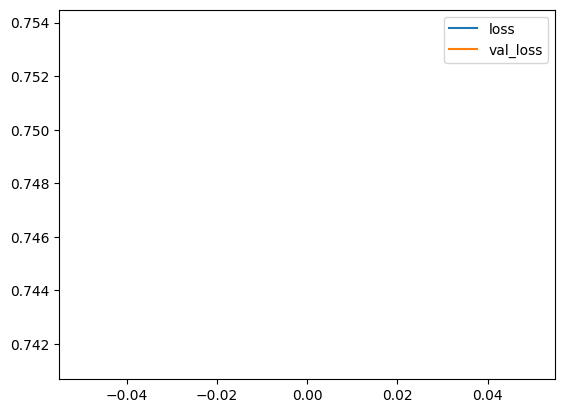

In [ ]:
plt.plot(history.history['loss'],     label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend(['loss', 'val_loss'])

In [ ]:
print(X_train_punc.shape)
print(X_test_punc.shape)

(6890, 9)
(1723, 9)


In [ ]:
concat       = concatenate([lstm_model.output, dense_model.output])
concat       = Dense(6, activation='sigmoid')(concat)
concat       = Dense(1, activation='sigmoid')(concat) # Changed from 3 to 1
model        = Model(inputs=[lstm_model.input, dense_model.input], outputs=concat)

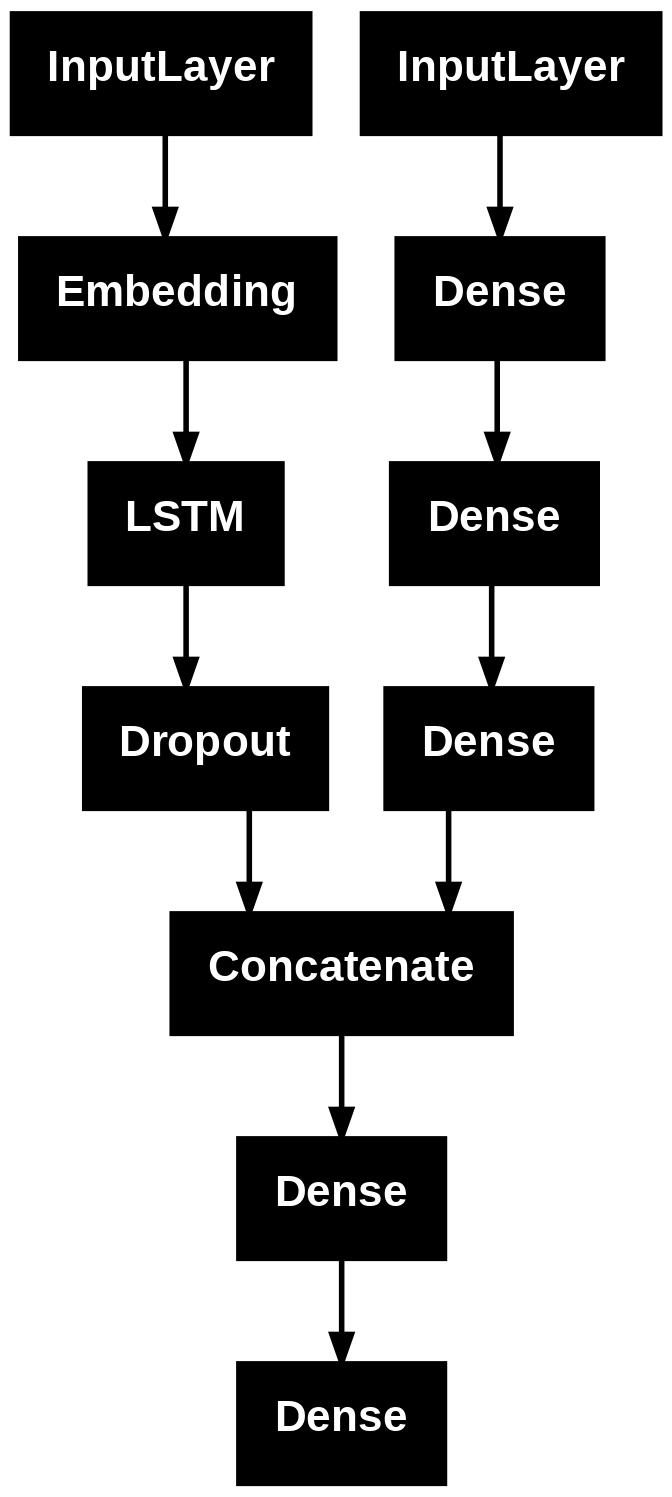

In [ ]:
plot_model(model)

In [ ]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['acc']
)

In [ ]:
history = model.fit(
    [X_train_title, X_train_punc],
    y_train,
    batch_size=64,
    class_weight=class_weight_dict,
    validation_data=([X_test_title, X_test_punc], y_test)
)

108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - acc: 0.6472 - loss: 0.6887 - val_acc: 0.7499 - val_loss: 0.6622


In [ ]:
print(type(X_train_title))
print(X_train_title.dtype)
print(type(X_train_punc))
print(X_train_punc.dtypes)

<class 'numpy.ndarray'>
int32
<class 'pandas.core.frame.DataFrame'>
uppercase_count      int64
lowercase_count      int64
number_count         int64
dot_count            int64
comma_count          int64
question_count       int64
exclamation_count    int64
semicolon_count      int64
fullstop_count       int64
dtype: object


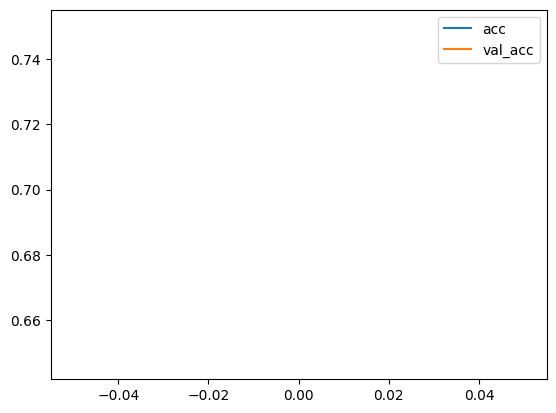

In [ ]:
plt.plot(history.history['acc'],     label='acc')
plt.plot(history.history['val_acc'], label='val_acc')
plt.legend(['acc', 'val_acc'])

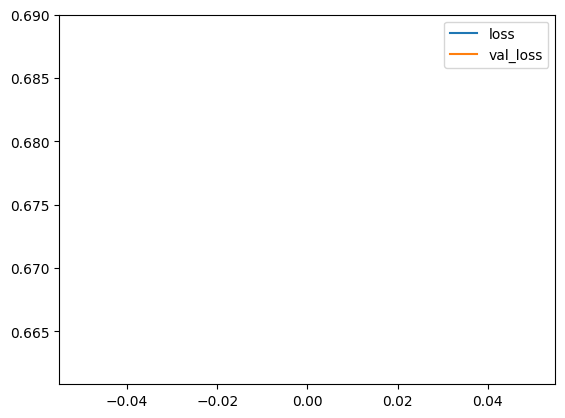

In [ ]:
plt.plot(history.history['loss'],     label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend(['loss', 'val_loss'])

done